# ROC Curve

The **ROC (Receiver Operating Characteristic) Curve** is used to evaluate the performance of a classification model at different classification thresholds.

Instead of using a fixed threshold (like 0.5), ROC shows how the model behaves across all possible thresholds.

It helps us understand how well the model separates classes.

## Key Idea

The ROC curve plots:

- **True Positive Rate (TPR)** vs **False Positive Rate (FPR)**

## Definitions

### True Positive Rate (TPR)
Also called **Recall or Sensitivity**

\[
TPR = \frac{TP}{TP + FN}
\]

It measures how many actual positives are correctly predicted.

### False Positive Rate (FPR)

\[
FPR = \frac{FP}{FP + TN}
\]

It measures how many actual negatives are incorrectly predicted as positive.

## ROC Curve Plot

- X-axis → False Positive Rate (FPR)
- Y-axis → True Positive Rate (TPR)

Each point on the curve represents a different threshold.

## Why ROC Curve is Important

- Shows model performance across all thresholds
- Helps compare different classification models
- Useful when classes are imbalanced
- A model closer to the top-left corner is better

## AUC (Area Under Curve)

- AUC measures the overall performance of the ROC curve
- Value ranges from **0 to 1**
  - 1 → Perfect model
  - 0.5 → Random model
  - < 0.5 → Poor model

### Import libraries

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

### Load Dataset
***Here, the breast cancer dataset from scikit-learn is used***

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Model

In [3]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Get Prediction Probabilities

In [4]:
y_prob = model.predict_proba(X_test)[:, 1]

### Compute ROC Curve

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.9952505732066819


### Plot ROC Curve 

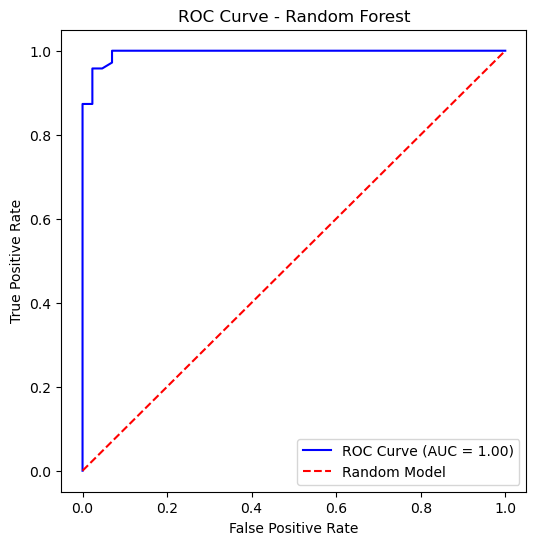

In [6]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

### What this shows
- Blue curve → model performance
- Red dashed line → random guessing baseline
- Closer curve is to top-left → better model